In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed/02_split")
PROCESSED_DIR.mkdir(exist_ok=True)

# ============================================================
# Hàm chuẩn hóa to_hop_thi về đúng dạng mã ngắn (VD: "A00")
# Áp dụng ngay từ gốc để toàn bộ pipeline dùng chung 1 định dạng,
# không cần vá lại ở các giai đoạn sau
# ============================================================
def chuan_hoa_to_hop(gia_tri):
    """'A00 (Toán, Lý, Hóa)' -> 'A00'; 'A00' -> 'A00' (giữ nguyên nếu đã ngắn)"""
    return str(gia_tri).split()[0]

# ============================================================
# Đọc dữ liệu khảo sát thật (đây là NGUỒN DUY NHẤT dùng để tách test)
# ============================================================
df = pd.read_csv(RAW_DIR / "khao_sat_dinh_huong_nganh_hoc_clean.csv")
print(f"Tổng số dòng khảo sát: {len(df)}")
print(f"Số ngành: {df['nganh_hoc'].nunique()}")

# ============================================================
# CHUẨN HÓA to_hop_thi ngay từ đầu
# ============================================================
print(f"\nVí dụ trước khi chuẩn hóa: {df['to_hop_thi'].iloc[0]}")
df['to_hop_thi'] = df['to_hop_thi'].apply(chuan_hoa_to_hop)
print(f"Ví dụ sau khi chuẩn hóa: {df['to_hop_thi'].iloc[0]}")
print(f"\nCác giá trị tổ hợp sau chuẩn hóa: {sorted(df['to_hop_thi'].unique())}")

# ============================================================
# Xử lý ngành có <2 mẫu — không đủ để stratify, giữ nguyên vào train
# ============================================================
counts = df['nganh_hoc'].value_counts()
nganh_du_de_tach = counts[counts >= 2].index

df_split_ok = df[df['nganh_hoc'].isin(nganh_du_de_tach)].copy()
df_qua_it = df[~df['nganh_hoc'].isin(nganh_du_de_tach)].copy()

print(f"\nSố ngành đủ mẫu để stratify: {len(nganh_du_de_tach)}")
print(f"Số ngành quá ít (<2 mẫu), giữ nguyên vào train: {df['nganh_hoc'].nunique() - len(nganh_du_de_tach)}")

# ============================================================
# Tách Train/Test — 85/15, stratified theo ngành
# ============================================================
df_train, df_test = train_test_split(
    df_split_ok,
    test_size=0.15,
    stratify=df_split_ok['nganh_hoc'],
    random_state=42
)

# Gộp phần "quá ít mẫu" luôn vào train (không đưa vào test)
df_train = pd.concat([df_train, df_qua_it], ignore_index=True)
df_test = df_test.reset_index(drop=True)

print(f"\n=== KẾT QUẢ TÁCH ===")
print(f"Train: {len(df_train)} dòng")
print(f"Test: {len(df_test)} dòng")

# ============================================================
# Kiểm tra lại — liệt kê ngành có ít hơn 3 dòng trong test (đáng lưu ý)
# ============================================================
test_counts = df_test['nganh_hoc'].value_counts()
print(f"\nCác ngành có <3 dòng trong test (cần ghi chú hạn chế ở Chương 4):")
print(test_counts[test_counts < 3].sort_values())

# ============================================================
# Lưu kết quả — ĐÂY LÀ ĐIỂM MỐC QUAN TRỌNG NHẤT
# Từ giờ trở đi, KHÔNG được đụng vào df_test dưới bất kỳ hình thức nào
# cho tới bước đánh giá mô hình cuối cùng (Giai đoạn 7)
# ============================================================
df_train.to_csv(PROCESSED_DIR / "khaosat_train.csv", index=False, encoding='utf-8-sig')
df_test.to_csv(PROCESSED_DIR / "khaosat_test_KHONG_DUNG_TOI.csv", index=False, encoding='utf-8-sig')

print(f"\n✅ Đã lưu:")
print(f"   {PROCESSED_DIR / 'khaosat_train.csv'}")
print(f"   {PROCESSED_DIR / 'khaosat_test_KHONG_DUNG_TOI.csv'}")

Tổng số dòng khảo sát: 766
Số ngành: 39

Ví dụ trước khi chuẩn hóa: A01 (Toán, Lý, Anh)
Ví dụ sau khi chuẩn hóa: A01

Các giá trị tổ hợp sau chuẩn hóa: ['A00', 'A01', 'B00', 'B08', 'C00', 'C01', 'C02', 'C03', 'D01', 'D07', 'D09', 'D14', 'D15', 'X01', 'X26']

Số ngành đủ mẫu để stratify: 39
Số ngành quá ít (<2 mẫu), giữ nguyên vào train: 0

=== KẾT QUẢ TÁCH ===
Train: 651 dòng
Test: 115 dòng

Các ngành có <3 dòng trong test (cần ghi chú hạn chế ở Chương 4):
nganh_hoc
Quản lý Công nghiệp                        1
Công nghệ kỹ thuật môi trường              1
Kinh doanh thời trang và dệt may           1
Công nghệ chế biến thủy sản                1
Luật                                       1
Khoa học chế biến món ăn                   1
Quản lý tài nguyên và môi trường           1
Đảm bảo chất lượng và an toàn thực phẩm    1
Logistics và quản lý chuỗi cung ứng        2
Khoa học dinh dưỡng và ẩm thực             2
An toàn thông tin                          2
Công nghệ chế tạo máy             

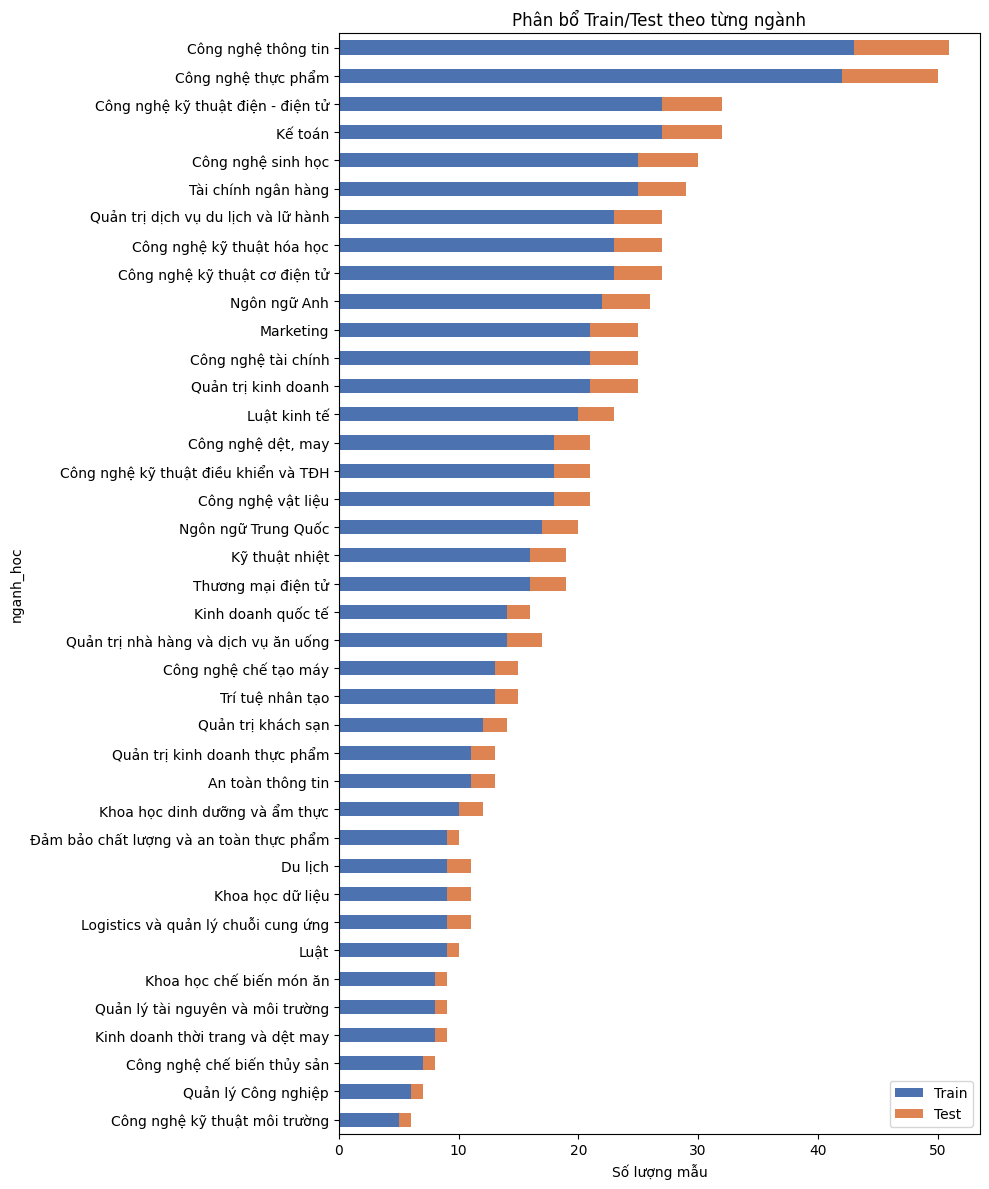

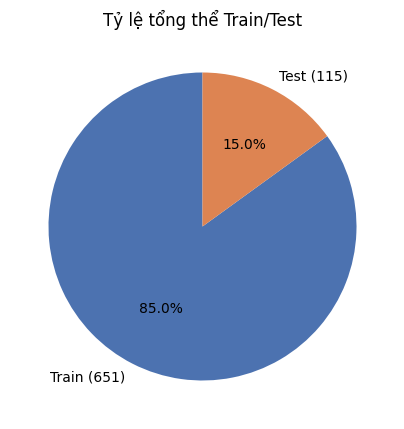


⚠️ 18/39 ngành có <3 dòng trong test set:
nganh_hoc
Quản lý Công nghiệp                        1
Công nghệ kỹ thuật môi trường              1
Kinh doanh thời trang và dệt may           1
Công nghệ chế biến thủy sản                1
Luật                                       1
Khoa học chế biến món ăn                   1
Quản lý tài nguyên và môi trường           1
Đảm bảo chất lượng và an toàn thực phẩm    1
Logistics và quản lý chuỗi cung ứng        2
Khoa học dinh dưỡng và ẩm thực             2
An toàn thông tin                          2
Công nghệ chế tạo máy                      2
Kinh doanh quốc tế                         2
Khoa học dữ liệu                           2
Quản trị khách sạn                         2
Quản trị kinh doanh thực phẩm              2
Trí tuệ nhân tạo                           2
Du lịch                                    2


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Nếu chữ Việt bị lỗi font khi hiển thị, bỏ comment dòng dưới và chỉnh path font có dấu
# plt.rcParams['font.family'] = 'DejaVu Sans'

# ============================================================
# BIỂU ĐỒ 1 — So sánh số lượng mẫu Train vs Test theo từng ngành
# ============================================================
train_counts = df_train['nganh_hoc'].value_counts()
test_counts = df_test['nganh_hoc'].value_counts()

compare = pd.DataFrame({'Train': train_counts, 'Test': test_counts}).fillna(0)
compare = compare.sort_values('Train', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
compare.plot(kind='barh', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_xlabel('Số lượng mẫu')
ax.set_title('Phân bổ Train/Test theo từng ngành')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'bieu_do_train_test_theo_nganh.png', dpi=150)
plt.show()

# ============================================================
# BIỂU ĐỒ 2 — Tỷ lệ tổng thể Train/Test (pie chart)
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([len(df_train), len(df_test)],
       labels=[f'Train ({len(df_train)})', f'Test ({len(df_test)})'],
       autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
ax.set_title('Tỷ lệ tổng thể Train/Test')
plt.savefig(PROCESSED_DIR / 'bieu_do_ty_le_train_test.png', dpi=150)
plt.show()

# ============================================================
# BẢNG — Cảnh báo ngành có <3 dòng test (không đủ ý nghĩa thống kê)
# ============================================================
test_it = test_counts[test_counts < 3].sort_values()
print(f"\n⚠️ {len(test_it)}/{len(test_counts)} ngành có <3 dòng trong test set:")
print(test_it.to_string())